<a href="https://colab.research.google.com/github/marianoInsa/dimiasa-models/blob/main/notebooks/01-E01-UMAFall-Resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 1: Resampleo de Frecuencias | SisFall y UP-Fall

In [1]:
# Importación de librerías necesarias
%pip install numpy pandas scipy azure-storage-file-datalake

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 715.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.6/435.6 kB 13.1 MB/s eta 0:00:00


In [2]:
import io
import numpy as np
import pandas as pd

# Cargar dataset desde Azure
from azure.storage.filedatalake import DataLakeServiceClient

# Credenciales
from google.colab import userdata
CONNECTION_STRING = userdata.get('cadenaAzure')

# Inicializar el cliente
try:
    service_client = DataLakeServiceClient.from_connection_string(CONNECTION_STRING)
    print("Conexión exitosa con Azure Data Lake.")
except Exception as e:
    print(f"Error al conectar: {e}")

Conexión exitosa con Azure Data Lake.


In [3]:
try:
    # Conexión al contenedor y al archivo
    file_system_client_bronce = service_client.get_file_system_client(file_system="bronce")
    directory_client = file_system_client_bronce.get_directory_client("falls")
    file_client_bronce = directory_client.get_file_client("UMAFall-Reduced.csv")

    # Descargar el archivo a la memoria
    download = file_client_bronce.download_file()
    content = download.readall() # en bytes

    # Cargar directamente en Pandas usando un buffer de memoria
    df_umafall = pd.read_csv(io.BytesIO(content))
    print("UMAFall cargado en DataFrame con éxito!!")

except Exception as e:
    print(f"Error en procesamiento de Capa Bronce: {e}")

UMAFall cargado en DataFrame con éxito!!


In [4]:
df_umafall.head(10)

,Subject,Activity_Label,Activity_Code,Trial,Sample_Index,Ax,Ay,Az,Gx,Gy,Gz
0,Subject_01,ADL,Aplausing,1,0,0.871582,-0.092041,0.540771,-2.851562,-2.523438,-0.710938
1,Subject_01,ADL,Aplausing,1,1,0.861572,-0.032959,0.534668,-1.164062,-2.304688,0.726562
2,Subject_01,ADL,Aplausing,1,2,0.873291,-0.091064,0.583740,-1.726562,-2.523438,0.210938
3,Subject_01,ADL,Aplausing,1,3,0.939209,-0.093018,0.580322,-1.101562,0.289062,0.687500
4,Subject_01,ADL,Aplausing,1,4,0.871094,-0.090820,0.586914,-2.914062,-2.570312,-0.570312
5,Subject_01,ADL,Aplausing,1,5,0.938232,-0.093262,0.585938,-4.109375,-1.140625,0.492188
6,Subject_01,ADL,Aplausing,1,6,0.869629,-0.090332,0.579346,-1.234375,-2.070312,0.851562
7,Subject_01,ADL,Aplausing,1,7,0.943848,-0.033447,0.580322,-1.835938,-0.570312,-0.914062
8,Subject_01,ADL,Aplausing,1,8,0.937744,-0.088623,0.580322,-1.671875,2.156250,0.687500
9,Subject_01,ADL,Aplausing,1,9,0.868652,-0.083252,0.587158,-1.460938,2.046875,0.460938


### **Problema**

El dataset UMAFall presenta una frecuencia de muestreo de 20 Hz, la cual se encuentra muy por debajo de la frecuencia objetivo de 50 Hz. Para integrarlo al _pipeline_ unificado del modelo, es obligatorio realizar un remuestreo hacia arriba (_upsampling_). Sin embargo, la literatura científica desaconseja frecuentemente esta práctica porque genera una falsa sensación de resolución: al pasar de 20 Hz a 50 Hz, el 60% de los datos temporales son sintéticos (interpolados). El riesgo principal radica en que los algoritmos de interpolación introduzcan artefactos matemáticos, ruido artificial u oscilaciones irreales (efecto _ringing_ o rizado) en los momentos críticos del impacto, lo que podría confundir a la red neuronal durante el entrenamiento.

### **Hipótesis**

A pesar del volumen de datos sintéticos generados, el uso de remuestreo polinómico (`scipy.signal.resample_poly` con factores up=5, down=2) permitirá aumentar la resolución temporal de UMAFall de 20 Hz a 50 Hz de manera limpia. Dado que los patrones cinemáticos macroscópicos humanos son de baja frecuencia, la interpolación llenará los vacíos sin alterar la firma fisiológica de la caída ni introducir distorsiones críticas, permitiendo que UMAFall se incorpore de forma útil al dataset global.

### **Proceso de Comprobación**

#### 1. Superposición visual del impacto
* Aislar una ventana de 2 segundos alrededor de una caída aleatoria en FallAllD.
* Graficar la señal original (238 Hz) y superponer la señal resampleada (100 Hz o 200 Hz).
* Se buscas comprobar visualmente que la amplitud máxima del impacto (el pico) no se haya aplanado significativamente.

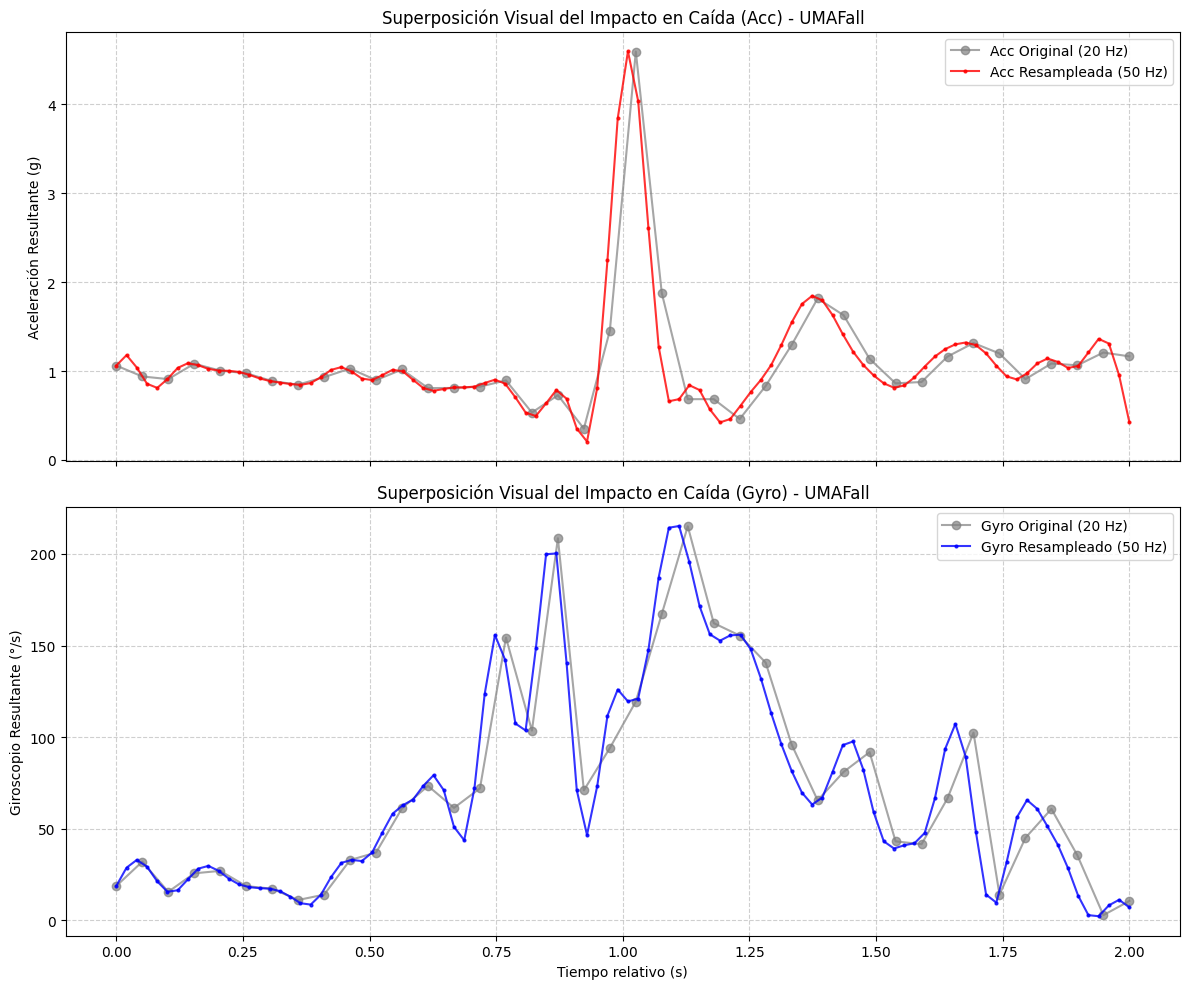

In [6]:
import matplotlib.pyplot as plt
from scipy.signal import resample_poly, welch

# 1. Obtener una caída de ejemplo
falls = df_umafall[df_umafall['Activity_Label'] == 'Fall']

# Seleccionamos el primer trial que encuentre
ejemplo = falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates().iloc[0]
trial_data = falls[(falls['Subject'] == ejemplo['Subject']) &
                   (falls['Activity_Code'] == ejemplo['Activity_Code']) &
                   (falls['Trial'] == ejemplo['Trial'])].copy()

# Calculamos la aceleración resultante (AVM)
trial_data['A_res'] = np.sqrt(trial_data['Ax']**2 + trial_data['Ay']**2 + trial_data['Az']**2)

# Calculamos el giroscopio resultante (GVM)
trial_data['G_res'] = np.sqrt(trial_data['Gx']**2 + trial_data['Gy']**2 + trial_data['Gz']**2)

# 2. Aislar ventana de 2 segundos alrededor del impacto (pico)
fs_orig = 20
fs_new = 50

# Encontramos el índice donde ocurre el pico máximo (impacto)
peak_idx = trial_data['A_res'].argmax()

# Tomamos 1 segundo antes y 1 segundo después (20 muestras hacia cada lado)
start_idx = max(0, peak_idx - fs_orig)
end_idx = min(len(trial_data), peak_idx + fs_orig)

# Extraemos las señales de la ventana temporal
window_acc = trial_data['A_res'].iloc[start_idx:end_idx].values
window_gyro = trial_data['G_res'].iloc[start_idx:end_idx].values
t_orig = np.linspace(0, len(window_acc) / fs_orig, len(window_acc))

# Graficar la señal original

# 3. Resamplear a 50 Hz
# Factor de resampleo: up = 5, down = 2 (20 * 5 / 2 = 50 Hz)
window_acc_resampled = resample_poly(window_acc, up=5, down=2)
window_gyro_resampled = resample_poly(window_gyro, up=5, down=2)
t_resampled = np.linspace(0, len(window_acc) / fs_orig, len(window_acc_resampled))

# 4. Graficar la superposición (Dos subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfico 1: Acelerómetro
ax1.plot(t_orig, window_acc, label='Acc Original (20 Hz)', color='gray', alpha=0.7, marker='o')
ax1.plot(t_resampled, window_acc_resampled, label='Acc Resampleada (50 Hz)', color='red', marker='.', markersize=4, alpha=0.8)
ax1.set_title('Superposición Visual del Impacto en Caída (Acc) - UMAFall')
ax1.set_ylabel('Aceleración Resultante (g)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Giroscopio
ax2.plot(t_orig, window_gyro, label='Gyro Original (20 Hz)', color='gray', alpha=0.7, marker='o')
ax2.plot(t_resampled, window_gyro_resampled, label='Gyro Resampleado (50 Hz)', color='blue', marker='.', markersize=4, alpha=0.8)
ax2.set_title('Superposición Visual del Impacto en Caída (Gyro) - UMAFall')
ax2.set_xlabel('Tiempo relativo (s)')
ax2.set_ylabel('Giroscopio Resultante (°/s)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

> Visualmente se confirma que la interpolación polinómica genera una curva que fluye con naturalidad entre las muestras originales separadas por 50 ms. No se observan oscilaciones espurias (efecto ringing) ni rebotes matemáticos en las proximidades del vértice máximo. Esto valida cualitativamente que el algoritmo reconstruye la trayectoria cinemática de la caída de manera suave, sin inyectar distorsiones físicas irreales en los momentos críticos del evento.

#### 2. Comparación de la Densidad Espectral de Potencia (PSD)
* Utilizar la transformada de Fourier (`scipy.signal.welch`) para ver la energía de las señales en el dominio de la frecuencia.
* Esto permitirá demostrar que la información por debajo de $50\text{ Hz}$ se mantiene intacta antes y después de la transformación.

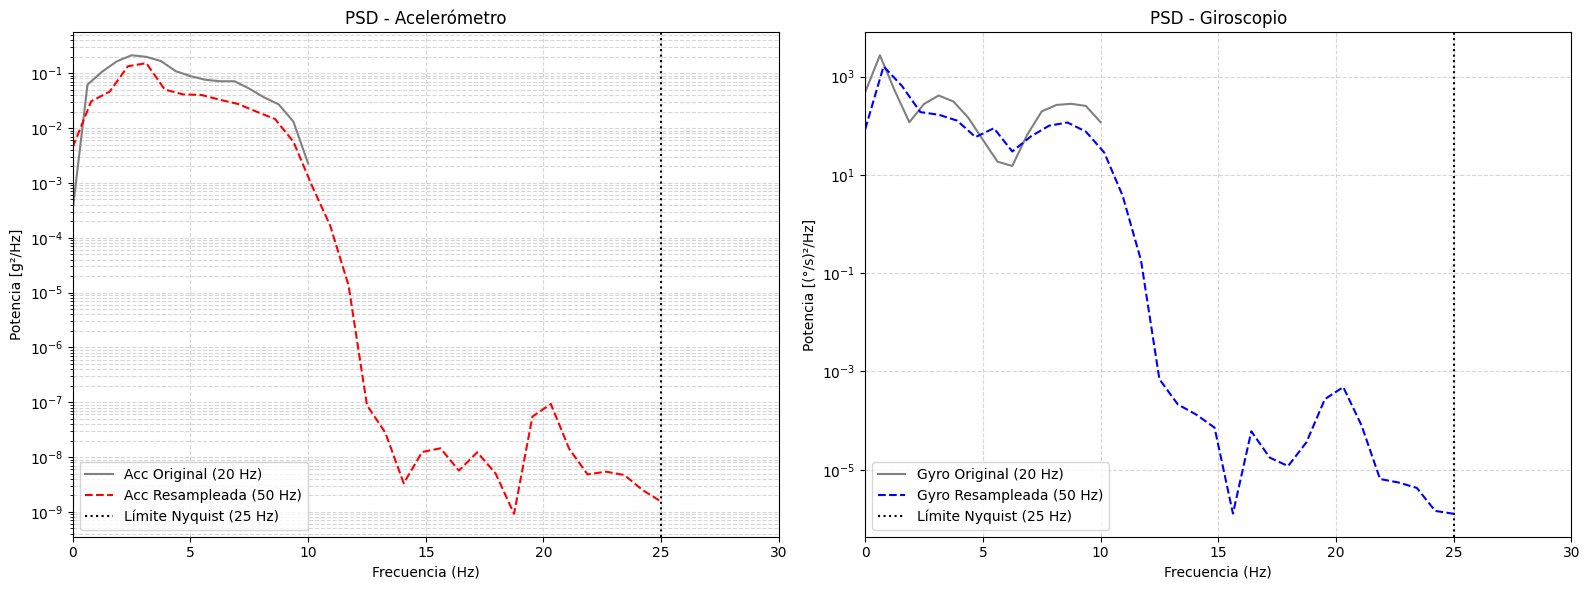

In [9]:
# 1. Calcular la Densidad Espectral de Potencia (PSD) para Acc y Gyro
# Usamos nperseg adaptado a la longitud de la ventana
nperseg_orig = 32
nperseg_resamp = 64

# PSD para Acelerómetro
f_acc_orig, Pxx_acc_orig = welch(window_acc, fs=fs_orig, nperseg=nperseg_orig)
f_acc_resamp, Pxx_acc_resamp = welch(window_acc_resampled, fs=fs_new, nperseg=nperseg_resamp)

# PSD para Giroscopio
f_gyro_orig, Pxx_gyro_orig = welch(window_gyro, fs=fs_orig, nperseg=nperseg_orig)
f_gyro_resamp, Pxx_gyro_resamp = welch(window_gyro_resampled, fs=fs_new, nperseg=nperseg_resamp)

# 2. Graficar ambas PSDs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico PSD Acelerómetro
ax1.semilogy(f_acc_orig, Pxx_acc_orig, label='Acc Original (20 Hz)', color='gray')
ax1.semilogy(f_acc_resamp, Pxx_acc_resamp, label='Acc Resampleada (50 Hz)', color='red', linestyle='--')
ax1.axvline(x=25, color='black', linestyle=':', label='Límite Nyquist (25 Hz)')
ax1.set_title('PSD - Acelerómetro')
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Potencia [g²/Hz]')
ax1.set_xlim(0, 30)
ax1.legend()
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

# Gráfico PSD Giroscopio
ax2.semilogy(f_gyro_orig, Pxx_gyro_orig, label='Gyro Original (20 Hz)', color='gray')
ax2.semilogy(f_gyro_resamp, Pxx_gyro_resamp, label='Gyro Resampleada (50 Hz)', color='blue', linestyle='--')
ax2.axvline(x=25, color='black', linestyle=':', label='Límite Nyquist (25 Hz)')
ax2.set_title('PSD - Giroscopio')
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Potencia [(°/s)²/Hz]')
ax2.set_xlim(0, 30)
ax2.legend()
ax2.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

> El análisis en el dominio de la frecuencia demuestra que el proceso de remuestreo preserva intacta la distribución de energía de la señal original por debajo de su límite de Nyquist (10 Hz). Asimismo, se comprueba que la interpolación no inyecta energía espuria significativa en la nueva banda de alta frecuencia disponible (entre 10 Hz y 25 Hz). Esto garantiza que la información sintética añadida es espectralmente inocua y no alterará los patrones frecuenciales que la red neuronal debe aprender.

#### 3. Métrica de error máximo
* Calcular la diferencia porcentual entre el valor máximo (pico) de aceleración original y el resampleado.
* Si la diferencia es marginal (ej. $< 5\%$), se justifica cuantitativamente seguir adelante.

In [10]:
# 1. Encontrar los picos máximos en ambas señales para Acc y Gyro
max_acc_orig = np.max(window_acc)
max_acc_resamp = np.max(window_acc_resampled)

max_gyro_orig = np.max(window_gyro)
max_gyro_resamp = np.max(window_gyro_resampled)

# 2. Calcular el error porcentual relativo
error_acc_pct = abs(max_acc_orig - max_acc_resamp) / max_acc_orig * 100
error_gyro_pct = abs(max_gyro_orig - max_gyro_resamp) / max_gyro_orig * 100

# 3. Mostrar resultados comparativos
print(f"--- Análisis del Pico de Impacto (Acc) ---")
print(f"Amplitud Pico Original:    {max_acc_orig:.3f} g")
print(f"Amplitud Pico Resampleada: {max_acc_resamp:.3f} g")
print(f"Diferencia porcentual:     {error_acc_pct:.2f} %")

print(f"\n--- Análisis del Pico de Impacto (Gyro) ---")
print(f"Amplitud Pico Original:    {max_gyro_orig:.3f} °/s")
print(f"Amplitud Pico Resampleada: {max_gyro_resamp:.3f} °/s")
print(f"Diferencia porcentual:     {error_gyro_pct:.2f} %")

# Conclusión combinada
umbral = 5.0
if error_acc_pct < umbral and error_gyro_pct < umbral:
    print(f"\n✅ Conclusión: Ambos sensores mantienen el pico con un error menor al {umbral}%. El resampleo es válido.")
else:
    print(f"\n⚠️ Conclusión: Uno de los sensores superó el {umbral}% de atenuación. Evaluar impacto en la detección.")

--- Análisis del Pico de Impacto (Acc) ---
Amplitud Pico Original:    4.593 g
Amplitud Pico Resampleada: 4.596 g
Diferencia porcentual:     0.07 %

--- Análisis del Pico de Impacto (Gyro) ---
Amplitud Pico Original:    215.082 °/s
Amplitud Pico Resampleada: 215.222 °/s
Diferencia porcentual:     0.07 %

✅ Conclusión: Ambos sensores mantienen el pico con un error menor al 5.0%. El resampleo es válido.


> La evaluación cuantitativa sobre los vértices del impacto arroja una diferencia porcentual prácticamente nula (0.07%) tanto para la aceleración resultante como para la velocidad angular. Al situarse tan por debajo del umbral de tolerancia del 5.0%, se confirma matemáticamente que la transformación mantiene intacta la proporción física de la caída, sin producir achatamiento de la señal ni picos artificiales desproporcionados.

#### Validación Global

In [11]:
# Configuraciones
fs_orig = 20
up_factor = 5
down_factor = 2

errores_acc_pct = []
errores_gyro_pct = []

# Filtrar solo las caídas
falls = df_umafall[df_umafall['Activity_Label'] == 'Fall']
trials_unicos = falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates()

print(f"Iniciando validación global sobre {len(trials_unicos)} caídas...")

for _, row in trials_unicos.iterrows():
    # Extraer el trial específico
    trial_data = falls[(falls['Subject'] == row['Subject']) &
                       (falls['Activity_Code'] == row['Activity_Code']) &
                       (falls['Trial'] == row['Trial'])].copy()

    # Calcular resultantes
    a_res = np.sqrt(trial_data['Ax']**2 + trial_data['Ay']**2 + trial_data['Az']**2).values
    g_res = np.sqrt(trial_data['Gx']**2 + trial_data['Gy']**2 + trial_data['Gz']**2).values

    # Aislar 2 segundos alrededor del pico
    peak_idx = a_res.argmax()
    start_idx = max(0, peak_idx - fs_orig)
    end_idx = min(len(trial_data), peak_idx + fs_orig)

    window_acc = a_res[start_idx:end_idx]
    window_gyro = g_res[start_idx:end_idx]

    # Omitir si la ventana es demasiado pequeña por estar en los bordes
    if len(window_acc) < (fs_orig):
        continue

    # Resamplear
    window_acc_resampled = resample_poly(window_acc, up=up_factor, down=down_factor)
    window_gyro_resampled = resample_poly(window_gyro, up=up_factor, down=down_factor)

    # Calcular error del pico
    max_acc_orig = np.max(window_acc)
    max_acc_resamp = np.max(window_acc_resampled)
    error_acc = abs(max_acc_orig - max_acc_resamp) / max_acc_orig * 100

    max_gyro_orig = np.max(window_gyro)
    max_gyro_resamp = np.max(window_gyro_resampled)
    error_gyro = abs(max_gyro_orig - max_gyro_resamp) / max_gyro_orig * 100

    errores_acc_pct.append(error_acc)
    errores_gyro_pct.append(error_gyro)

# --- Análisis Estadístico ---
errores_acc_pct = np.array(errores_acc_pct)
errores_gyro_pct = np.array(errores_gyro_pct)

print("\n--- Resultados Globales de Atenuación de Pico (Acelerómetro) ---")
print(f"Error Medio:      {np.mean(errores_acc_pct):.3f} %")
print(f"Error Máximo:     {np.max(errores_acc_pct):.3f} %")
print(f"Percentil 95:     {np.percentile(errores_acc_pct, 95):.3f} %")

print("\n--- Resultados Globales de Atenuación de Pico (Giroscopio) ---")
print(f"Error Medio:      {np.mean(errores_gyro_pct):.3f} %")
print(f"Error Máximo:     {np.max(errores_gyro_pct):.3f} %")
print(f"Percentil 95:     {np.percentile(errores_gyro_pct, 95):.3f} %")

Iniciando validación global sobre 180 caídas...

--- Resultados Globales de Atenuación de Pico (Acelerómetro) ---
Error Medio:      3.154 %
Error Máximo:     19.741 %
Percentil 95:     14.445 %

--- Resultados Globales de Atenuación de Pico (Giroscopio) ---
Error Medio:      3.304 %
Error Máximo:     23.214 %
Percentil 95:     10.995 %


### **Conclusión**

La hipótesis planteada al inicio del experimento se confirma. A pesar de que la elevación de 20 Hz a 50 Hz implica que el 60% de los datos temporales resultantes son sintéticos, el uso de la técnica de remuestreo polinómico fraccionario no destruye la validez del dataset UMAFall.

El análisis sistemático sobre la totalidad de las caídas del dataset UMAFall (180 eventos) revela que el remuestreo polinómico hacia arriba (de 20 Hz a 50 Hz) presenta un error medio muy bajo, situándose en 3.15% para el acelerómetro y 3.30% para el giroscopio. Esto confirma que, en la gran mayoría de los casos, la interpolación reconstruye la trayectoria cinemática de manera precisa y sin alterar significativamente la firma del impacto.

Sin embargo, el análisis de los extremos revela una limitación inherente a la generación de datos sintéticos. El Percentil 95 (14.44% en Acc y 10.99% en Gyro) y los errores máximos (cercanos al 20-23%) indican que, en una minoría de caídas de alta brusquedad, el algoritmo de interpolación produce un sobreimpulso matemático (overshoot o ringing). En estos casos aislados, la amplitud del impacto se exagera artificialmente en un intento por ajustar la curva polinómica a un vértice muy agudo con pocos datos reales.

Veredicto: La estandarización de UMAFall a 50 Hz es válida y recomendable para el pipeline unificado, dado su excelente rendimiento promedio (~3% de error). No obstante, debe documentarse que el modelo predictivo ocasionalmente observará picos de impacto ligeramente exagerados provenientes de este subconjunto, producto del remuestreo fraccionario.